# 本次模擬cmd log資訊

* 只保留run.log最後200行的資訊和AMReX finalize(如下)


In [1]:
from datetime import datetime, timedelta
import re

end_time = None
start_time = None
elapsed_hms = None

with open("run.log") as f:
    lines = [line.strip() for line in f if line.strip()]

# 最後一行 = End Time
end_time_str = lines[-1]
end_time = datetime.strptime(end_time_str, "%a %b %d %H:%M:%S %Z %Y")

# 找 Total run time
elapsed_sec = None

for line in lines:
    if line.startswith("Total run time"):
        m = re.search(r'([\d.]+)', line)
        if m:
            elapsed_sec = float(m.group(1))
        break

if elapsed_sec is not None:
    start_time = end_time - timedelta(seconds=elapsed_sec)

    h = int(elapsed_sec // 3600)
    m = int((elapsed_sec % 3600) // 60)
    s = int(elapsed_sec % 60)

    elapsed_hms = f"{h:02d}:{m:02d}:{s:02d}"

print("Simulation Information")
print("----------------------")
print(f"Start Time : {start_time.strftime('%a %b %d %H:%M:%S %Y')}")
print(f"End Time   : {end_time.strftime('%a %b %d %H:%M:%S %Y')}")
print(f"Run Time   : {elapsed_hms}")

Simulation Information
----------------------
Start Time : Mon Jun 29 18:10:26 2026
End Time   : Mon Jun 29 21:13:55 2026
Run Time   : 03:03:28


# 使用者設定

In [2]:
import re
from pathlib import Path

import yt
import numpy as np
import pandas as pd


# =========================
# User settings
# =========================#"/home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/"
PLOT_DIR = Path("./plts")          # plotfile 所在資料夾
PLOT_PREFIX = "plt"
PLOT_INTERVAL = 10000000           # 你的 plot_int，例如 100

# 如果你的 field 名稱不是 ("boxlib", "Phi")，後面會自動列出 field_list 方便你改
PHI_FIELD_CANDIDATES = [
    ("boxlib", "Phi"),
    ("boxlib", "phi"),
    ("boxlib", "PoissonPhi"),
    "Phi",
    "phi",
    "PoissonPhi",
]

wanted = {"alpha", "beta", "gamma", "BigGamma", "g11", "g44", "FE_lo", "FE_hi"}

def parse_value(values):
    vals = [float(v) for v in values.split()]
    return vals[0] if len(vals) == 1 else vals

params = {}

with open("inputs") as f:
    for line in f:
        line = line.strip()
        if not line or "=" not in line:
            continue

        key, values = line.split("=", 1)
        if key.strip() in wanted:
            params[key.strip()] = parse_value(values.strip())

# FE layer range, unit: nm
FE_Z_LO_NM = params["FE_lo"][2] / 1e-9
FE_Z_HI_NM = params["FE_hi"][2] / 1e-9

# 如果你想只畫 FE 的 x 範圍，也可以打開這兩行
# 若是 MFIS 全幅 FE，通常用整個 x 範圍即可

FE_X_LO_NM = params["FE_lo"][0] / 1e-9
FE_X_HI_NM = params["FE_hi"][0] / 1e-9

FE_Y_LO_NM = params["FE_lo"][1] / 1e-9
FE_Y_HI_NM = params["FE_hi"][1] / 1e-9

ALPHA = params["alpha"]
BETA = params["beta"]
SMALL_GAMMA = params["gamma"]
BIG_GAMMA = params["BigGamma"]
G11 = params["g11"]
G44 = params["g44"]
T_FE = 1e-9 * (FE_Z_HI_NM - FE_Z_LO_NM)  # FE layer thickness, unit: m

print("Parameters:")
print(f"  ALPHA = {ALPHA:.3e}")
print(f"  BETA = {BETA:.3e}")
print(f"  SMALL_GAMMA = {SMALL_GAMMA:.3e}")
print(f"  BIG_GAMMA = {BIG_GAMMA:.3e}")
print(f"  G11 = {G11:.3e}")
print(f"  G44 = {G44:.3e}")
print(f"  FE layer thickness = {T_FE:.3e} m")
# 3D sweep plot要畫的電壓欄位：-4.5, -4.0, ..., 4.5
VOLTAGES = np.arange(-4.5, 5.0, 0.5)
# 3D contour 要畫的plotfile


Parameters:
  ALPHA = -8.000e+09
  BETA = 3.600e+10
  SMALL_GAMMA = 1.500e+11
  BIG_GAMMA = 1.000e+02
  G11 = 1.000e-09
  G44 = 1.000e-09
  FE layer thickness = 8.000e-09 m


## Utils

In [3]:
def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names

In [4]:
from pathlib import Path
import yt


plot_paths = sorted([p for p in PLOT_DIR.glob(f"{PLOT_PREFIX}*") if p.is_dir()])

# 只要名稱 (plt000100, ...)
plot_names = [p.name for p in plot_paths]

print("Available plotfiles:")
for name in plot_names:
    print("  ", name)
    
print(len(plot_names), "plotfiles found in", PLOT_DIR)
PLOTFILE_NAME = plot_names[30] 


Available plotfiles:
   plt00000000
   plt00000643
   plt00000917
   plt00001322
   plt00002208
   plt00002661
   plt00003832
   plt00009707
   plt00011894
   plt00015668
   plt00017641
   plt00019509
   plt00020163
   plt00021023
   plt00021296
   plt00023826
   plt00024471
   plt00024985
   plt00025571
   plt00026429
   plt00027355
   plt00028381
   plt00028836
   plt00029717
   plt00031173
   plt00032502
   plt00038532
   plt00041515
   plt00048065
   plt00050923
   plt00051570
   plt00051904
   plt00052180
   plt00053297
   plt00053634
   plt00054977
   plt00055631
   plt00056194
   plt00056742
   plt00057644
   plt00058334
   plt00059056
   plt00059967
   plt00064471
   plt00066151
   plt00070502
   plt00072889
47 plotfiles found in plts


## 探索yt資料結構

### dir(ds) # 列出 ds 所有(variable和property和method)

* Note: variable和property和method統稱attribute

In [5]:
ds = yt.load(PLOT_DIR/plot_names[0])  # 載入指定的 plotfile
dir(ds) # 列出 ds 所有變數和屬性和方法
#[a for a in dir(ds) if not a.startswith("_")]

yt : [INFO     ] 2026-06-29 21:51:29,658 Parameters: current_time              = 0.0


yt : [INFO     ] 2026-06-29 21:51:29,658 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:29,659 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:29,659 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


['__abstractmethods__',
 '__annotate_func__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_add_object_class',
 '_arr',
 '_assign_unit_system',
 '_create_unit_registry',
 '_default_cparam_filename',
 '_determined_fields',
 '_field_info',
 '_field_info_class',
 '_field_list',
 '_find_extremum',
 '_force_periodicity',
 '_get_field_info',
 '_get_field_info_helper',
 '_guess_candidates',
 '_hash',
 '_header_mesh_start',
 '_index_class',
 '_input_filename',
 '_instantiated',
 '_instantiated_index',
 '_ionization_label_format',
 '_is_valid',
 '_is_withi

### 用key word查看dir(ds)中可能會用到的attribute

In [6]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "domain"
    if "domain" in a.lower():
        print(a)

_is_within_domain
domain_center
domain_dimensions
domain_left_edge
domain_offset
domain_right_edge
domain_width


In [7]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "field"
    if "field" in a.lower():
        print(a)

_determined_fields
_field_info
_field_info_class
_field_list
_get_field_info
_get_field_info_helper
add_deposited_particle_field
add_field
add_gradient_fields
add_mesh_sampling_particle_field
create_field_info
default_field
default_species_fields
derived_field_list
field_info
field_list
field_units
fields
fields_detected
find_field_values_at_point
find_field_values_at_points
particle_fields_by_type
set_field_label_format
setup_deprecated_fields


In [8]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "index"
    if "index" in a.lower():
        print(a)

_index_class
_instantiated_index
index


* **grid相關attribute在index內**

In [9]:
for a in dir(ds.index): # 列出 ds.index 裡有哪些屬性和方法，特別是包含 "index"
    if "grid" in a.lower():
        print(a)

_count_grids
_get_grid_objs
_get_grid_tree
_get_grids
_grid_chunksize
_grids
_initialize_grid_arrays
_populate_grid_objects
grid
grid_corners
grid_dimensions
grid_left_edge
grid_levels
grid_particle_count
grid_right_edge
grid_start_index
grids
lock_grids_to_parents
num_grids
select_grids


In [10]:
for a in dir(ds.index.grids[0]): # 列出 ds.index.grids[0] 裡有哪些屬性和方法，特別是包含 "index"
    
        print(a)

ActiveDimensions
Children
LeftEdge
Level
NumberOfParticles
OverlappingSiblings
Parent
RightEdge
__abstractmethods__
__add__
__and__
__annotate_func__
__class__
__delattr__
__delitem__
__dict__
__dir__
__doc__
__eq__
__firstlineno__
__format__
__ge__
__getattribute__
__getitem__
__getstate__
__gt__
__hash__
__init__
__init_subclass__
__int__
__invert__
__le__
__lt__
__module__
__ne__
__new__
__or__
__reduce__
__reduce_ex__
__repr__
__setattr__
__setitem__
__sizeof__
__slots__
__static_attributes__
__str__
__sub__
__subclasshook__
__weakref__
__xor__
_abc_impl
_activate_cache
_base_offset
_cache_mask
_child_index_mask
_child_indices
_child_mask
_children_ids
_chunk_info
_chunked_read
_compute_extrema
_con_args
_container_fields
_count_particles
_current_chunk
_current_fluid_type
_current_particle_type
_data_source
_debug
_default_field_parameters
_derived_quantity_chunking
_determine_fields
_distributed
_ds_hold
_extrema_cache
_field_cache
_field_lock
_field_parameter_state
_field_type_s

## yt dataset

* 可以從上一個部份"探索yt資料結構"找想用的attribute

In [11]:
print("========== Dataset ==========")
print("type:", type(ds))
print("用SI單位")
print("current_time(s):", ds.current_time)
print("domain_left_edge(m) :", ds.domain_left_edge)
print("domain_right_edge(m):", ds.domain_right_edge)
print("domain_center:", ds.domain_center)
print("domain_width(domain邊長):", ds.domain_width)
print("domain_offset:", ds.domain_offset)
print("domain_dimensions(xyz方向各切成幾格):", ds.domain_dimensions)
print("dimensionality:", ds.dimensionality)
print("geometry:", ds.geometry)
#print("periodicity:", ds.periodicity)

print("\n========== Fields ==========")
for f in ds.field_list:
    print(" ", f)


========== Dataset ==========
type: <class 'yt.frontends.amrex.data_structures.BoxlibDataset'>
用SI單位
current_time(s): 0.0 code_time
domain_left_edge(m) : [-1.6e-08 -1.6e-08  0.0e+00] code_length
domain_right_edge(m): [1.60e-08 1.60e-08 2.95e-08] code_length
domain_center: [0.000e+00 0.000e+00 1.475e-08] code_length
domain_width(domain邊長): [3.20e-08 3.20e-08 2.95e-08] code_length
domain_offset: [0 0 0]
domain_dimensions(xyz方向各切成幾格): [64 64 59]
dimensionality: 3
geometry: cartesian

========== Fields ==========
  ('boxlib', 'Ex')
  ('boxlib', 'Ey')
  ('boxlib', 'Ez')
  ('boxlib', 'Phi')
  ('boxlib', 'PhiDiff')
  ('boxlib', 'PoissonRHS')
  ('boxlib', 'Px')
  ('boxlib', 'Py')
  ('boxlib', 'Pz')
  ('boxlib', 'alpha')
  ('boxlib', 'beta')
  ('boxlib', 'charge')
  ('boxlib', 'electrons')
  ('boxlib', 'epsilon')
  ('boxlib', 'holes')
  ('boxlib', 'mask')
  ('boxlib', 'theta')
  ('boxlib', 'tphase')


* domain切成多個grid分配給mpi rank平行運算，**資料分散在每個grid**

In [12]:
print("\n========== Grids ==========")
print("number of grids:", len(ds.index.grids))
for i, g in enumerate(ds.index.grids):
    print(f"grid {i}:")
    print("  LeftEdge:", g.LeftEdge)
    print("  RightEdge:", g.RightEdge)
    print("  ActiveDimensions:", g.ActiveDimensions)
    print("  Level:", g.Level)
print(ds.index.grid_start_index)


========== Grids ==========
number of grids: 16
grid 0:
  LeftEdge: [-1.6e-08 -1.6e-08  0.0e+00] code_length
  RightEdge: [-8.00e-09 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 1:
  LeftEdge: [-8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 0.00e+00 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 2:
  LeftEdge: [ 0.0e+00 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 8.00e-09 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 3:
  LeftEdge: [ 8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 1.60e-08 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 4:
  LeftEdge: [-1.6e-08 -8.0e-09  0.0e+00] code_length
  RightEdge: [-8.00e-09  0.00e+00  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 5:
  LeftEdge: [-8.e-09 -8.e-09  0.e+00] code_length
  RightEdge: [0.00e+00 0.00e+00 2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level:

# plot

## **2Dfield繪製**

* g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
* x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置

yt : [INFO     ] 2026-06-29 21:51:29,746 Parameters: current_time              = 0.0


yt : [INFO     ] 2026-06-29 21:51:29,746 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:29,747 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:29,747 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


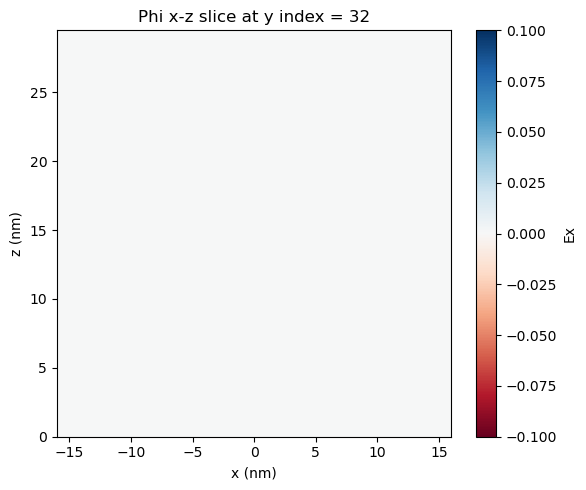

yt : [INFO     ] 2026-06-29 21:51:29,848 Parameters: current_time              = 1.286000000000001e-10


yt : [INFO     ] 2026-06-29 21:51:29,849 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:29,849 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:29,849 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


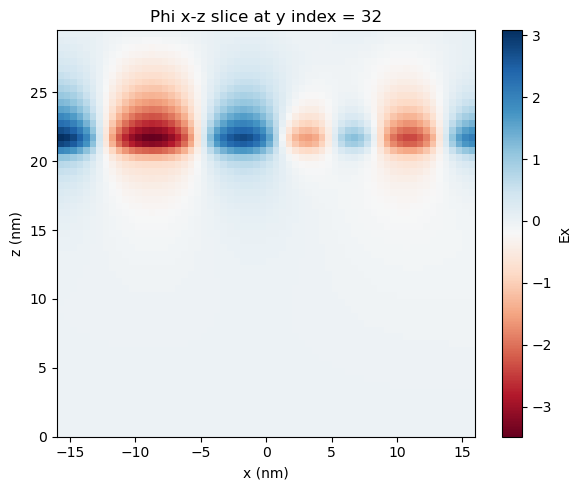

yt : [INFO     ] 2026-06-29 21:51:29,938 Parameters: current_time              = 1.8340000000000275e-10


yt : [INFO     ] 2026-06-29 21:51:29,938 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:29,938 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:29,938 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


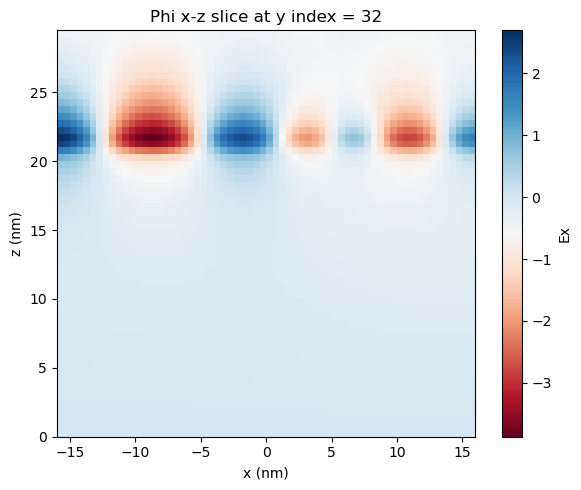

yt : [INFO     ] 2026-06-29 21:51:30,094 Parameters: current_time              = 2.6440000000000666e-10


yt : [INFO     ] 2026-06-29 21:51:30,095 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:30,095 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:30,095 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


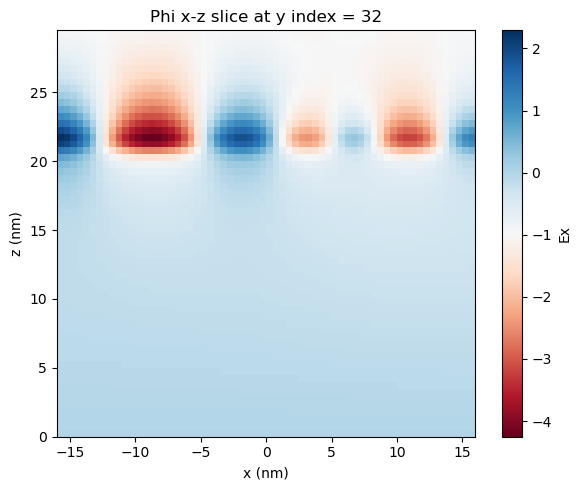

yt : [INFO     ] 2026-06-29 21:51:30,182 Parameters: current_time              = 4.416000000000152e-10


yt : [INFO     ] 2026-06-29 21:51:30,182 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:30,182 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:30,183 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


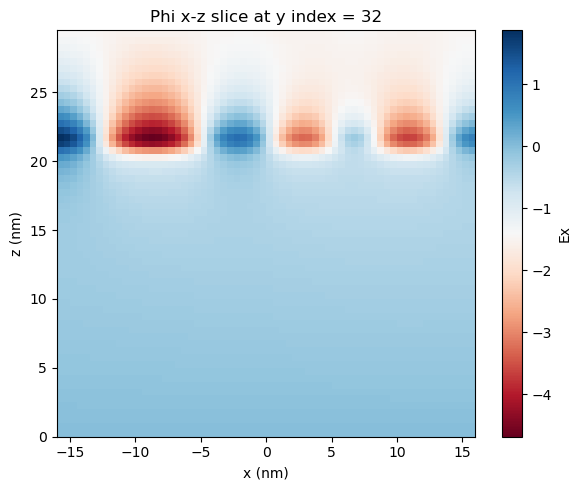

yt : [INFO     ] 2026-06-29 21:51:30,269 Parameters: current_time              = 5.322000000000024e-10


yt : [INFO     ] 2026-06-29 21:51:30,269 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:30,269 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:30,270 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


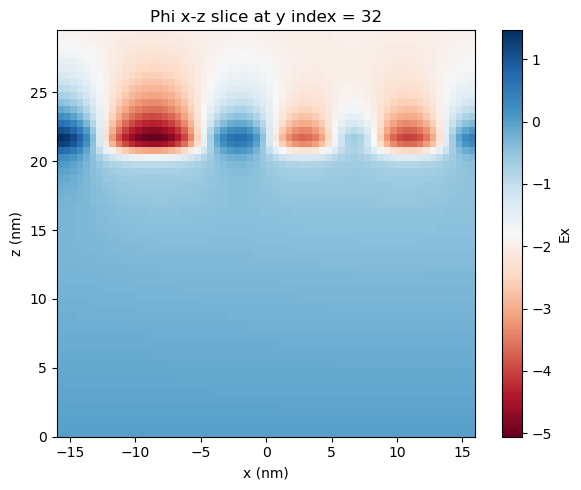

yt : [INFO     ] 2026-06-29 21:51:30,358 Parameters: current_time              = 7.663999999999531e-10


yt : [INFO     ] 2026-06-29 21:51:30,358 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:30,358 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:30,358 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


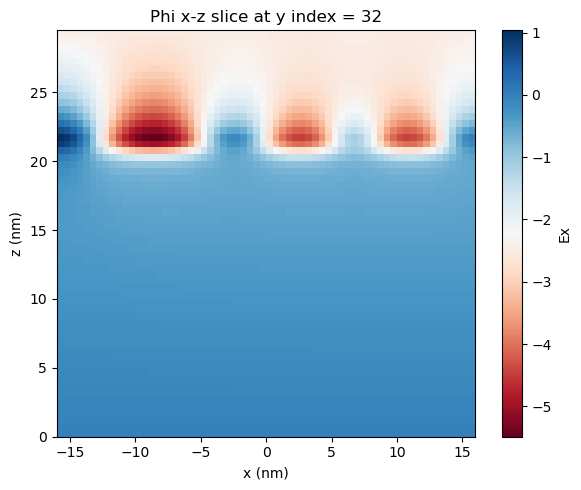

yt : [INFO     ] 2026-06-29 21:51:30,448 Parameters: current_time              = 1.9414000000002282e-09


yt : [INFO     ] 2026-06-29 21:51:30,448 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:30,448 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:30,449 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


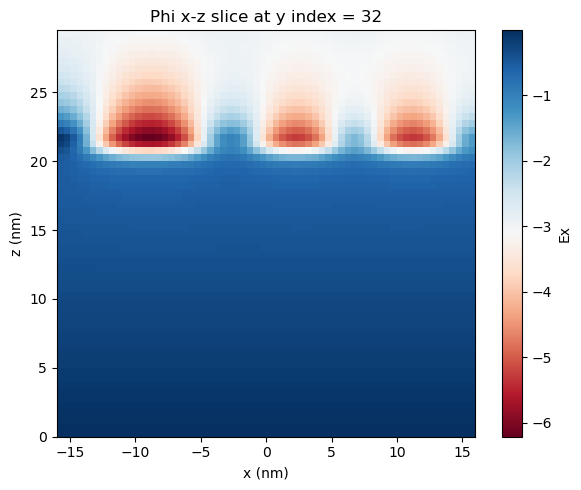

yt : [INFO     ] 2026-06-29 21:51:30,537 Parameters: current_time              = 2.3788000000003624e-09


yt : [INFO     ] 2026-06-29 21:51:30,537 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:30,537 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:30,537 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


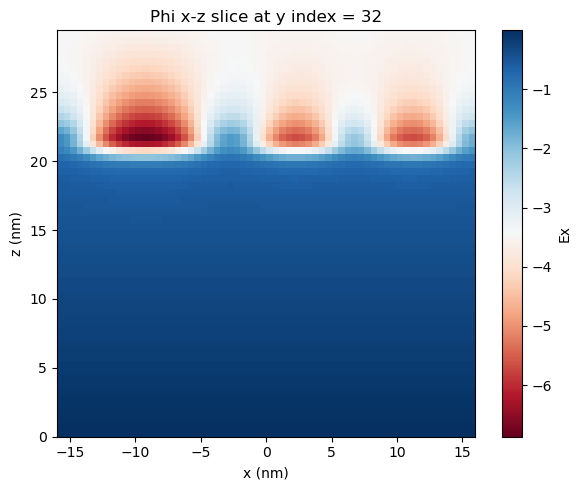

yt : [INFO     ] 2026-06-29 21:51:30,626 Parameters: current_time              = 3.133600000000594e-09


yt : [INFO     ] 2026-06-29 21:51:30,626 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:30,626 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:30,627 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


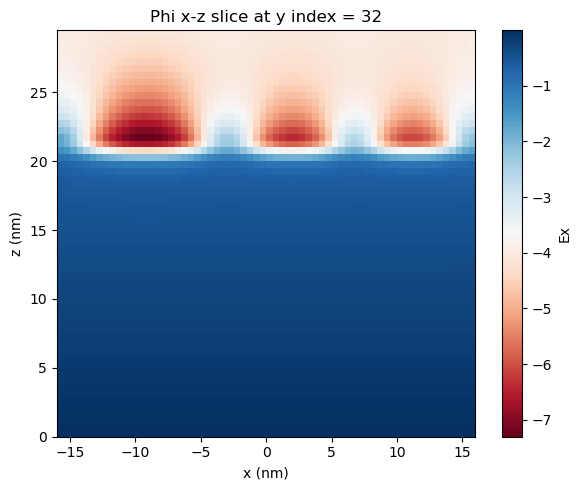

yt : [INFO     ] 2026-06-29 21:51:30,715 Parameters: current_time              = 3.528200000000715e-09


yt : [INFO     ] 2026-06-29 21:51:30,715 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:30,715 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:30,715 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


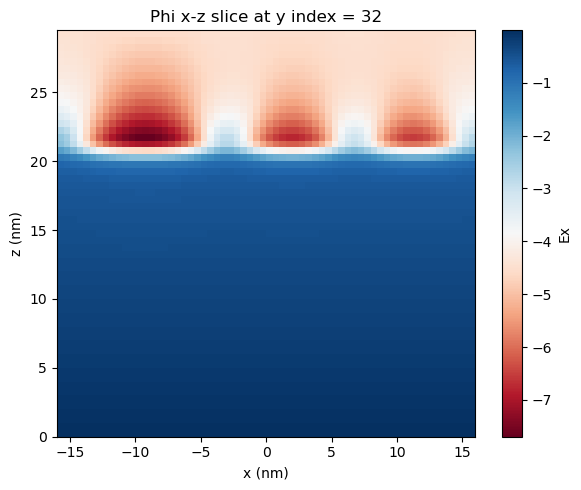

yt : [INFO     ] 2026-06-29 21:51:30,808 Parameters: current_time              = 3.9018000000008296e-09


yt : [INFO     ] 2026-06-29 21:51:30,809 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:30,809 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:30,809 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


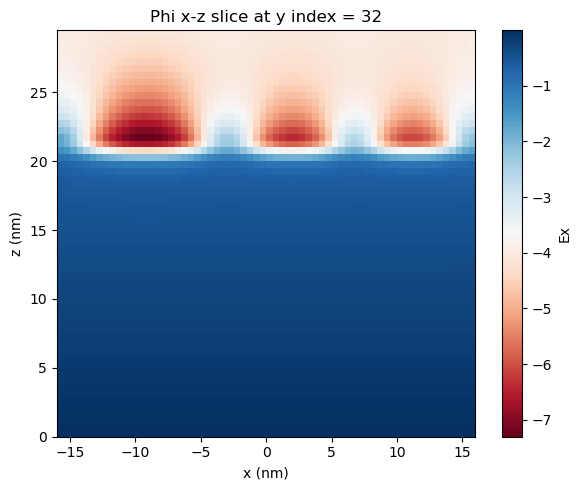

yt : [INFO     ] 2026-06-29 21:51:30,903 Parameters: current_time              = 4.03260000000087e-09


yt : [INFO     ] 2026-06-29 21:51:30,903 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:30,903 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:30,903 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


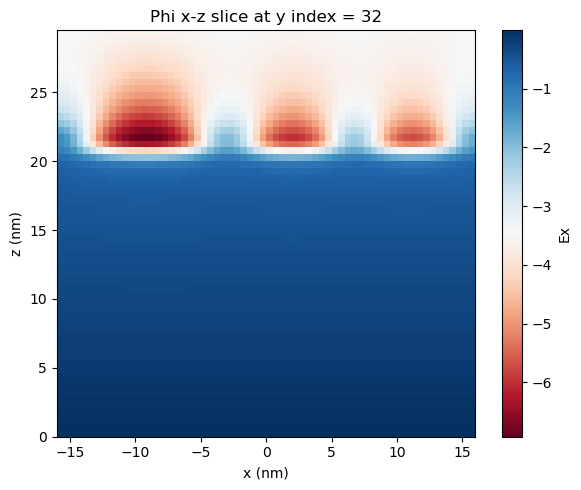

yt : [INFO     ] 2026-06-29 21:51:30,996 Parameters: current_time              = 4.2046000000009224e-09


yt : [INFO     ] 2026-06-29 21:51:30,996 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:30,997 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:30,997 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


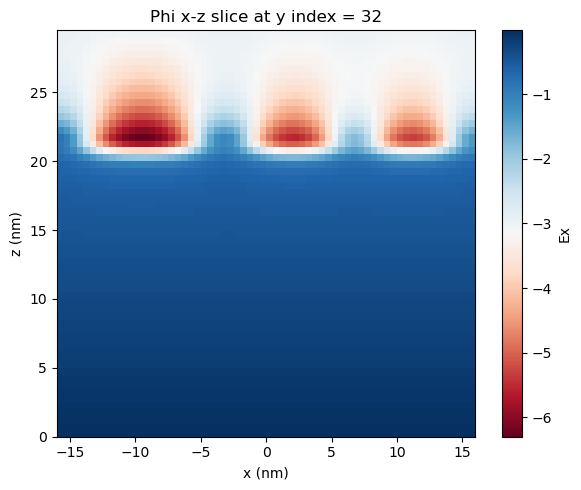

yt : [INFO     ] 2026-06-29 21:51:31,089 Parameters: current_time              = 4.259200000000939e-09


yt : [INFO     ] 2026-06-29 21:51:31,089 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:31,089 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:31,089 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


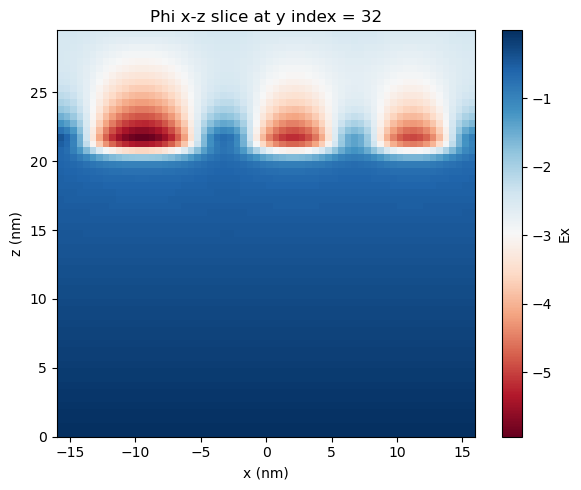

yt : [INFO     ] 2026-06-29 21:51:31,302 Parameters: current_time              = 4.765200000001094e-09


yt : [INFO     ] 2026-06-29 21:51:31,302 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:31,303 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:31,303 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


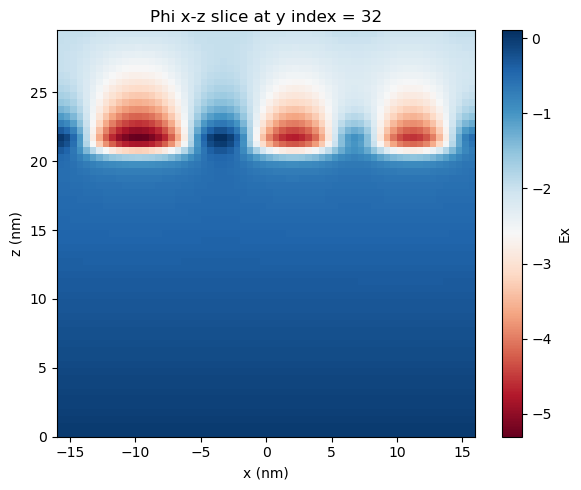

yt : [INFO     ] 2026-06-29 21:51:31,394 Parameters: current_time              = 4.894200000001134e-09


yt : [INFO     ] 2026-06-29 21:51:31,394 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:31,394 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:31,395 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


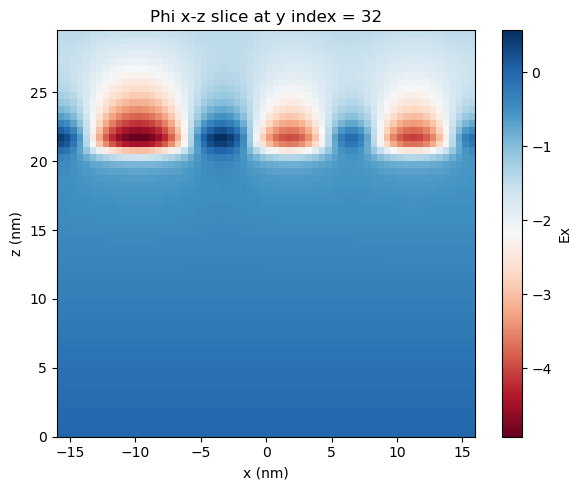

yt : [INFO     ] 2026-06-29 21:51:31,486 Parameters: current_time              = 4.9970000000011655e-09


yt : [INFO     ] 2026-06-29 21:51:31,487 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:31,487 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:31,487 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


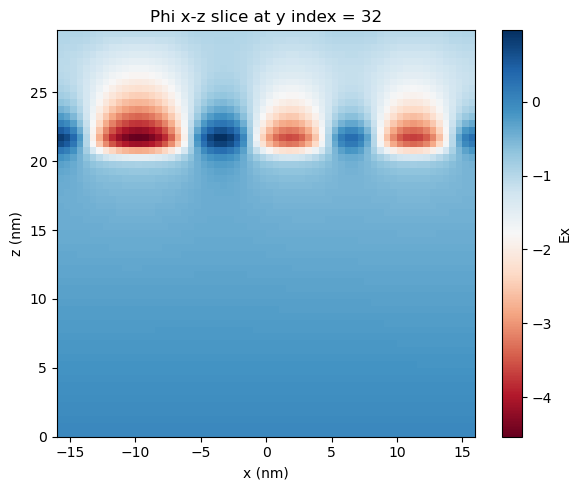

yt : [INFO     ] 2026-06-29 21:51:31,578 Parameters: current_time              = 5.1142000000012015e-09


yt : [INFO     ] 2026-06-29 21:51:31,579 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:31,579 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:31,579 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


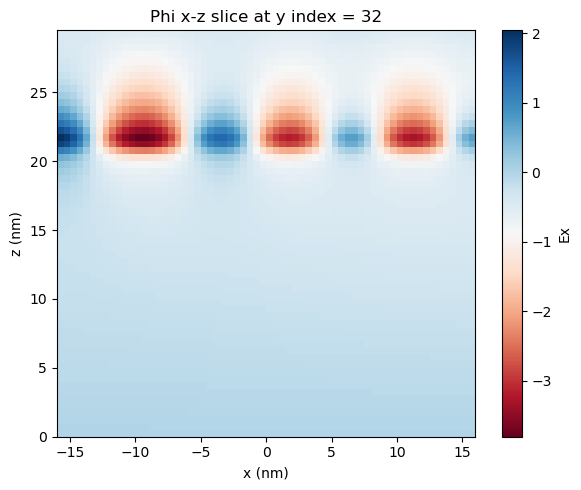

yt : [INFO     ] 2026-06-29 21:51:31,670 Parameters: current_time              = 5.285800000001254e-09


yt : [INFO     ] 2026-06-29 21:51:31,671 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:31,671 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:31,671 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


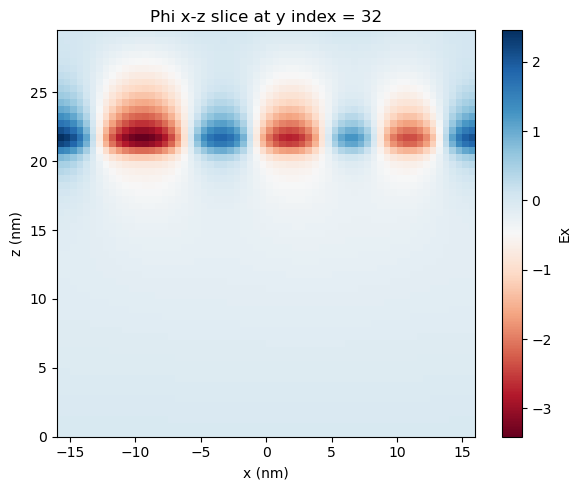

yt : [INFO     ] 2026-06-29 21:51:31,763 Parameters: current_time              = 5.471000000001311e-09


yt : [INFO     ] 2026-06-29 21:51:31,763 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:31,763 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:31,763 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


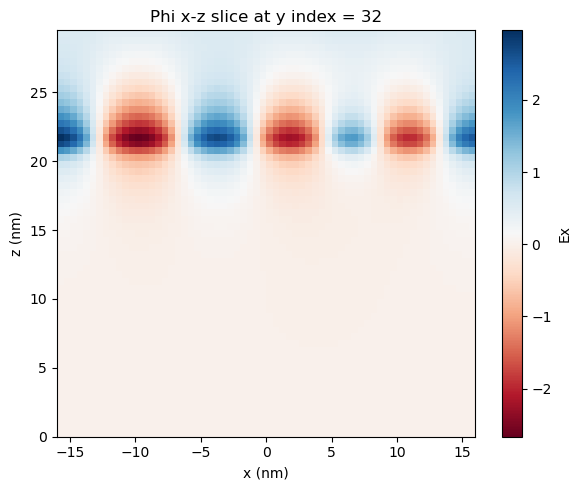

yt : [INFO     ] 2026-06-29 21:51:31,854 Parameters: current_time              = 5.676200000001374e-09


yt : [INFO     ] 2026-06-29 21:51:31,854 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:31,855 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:31,855 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


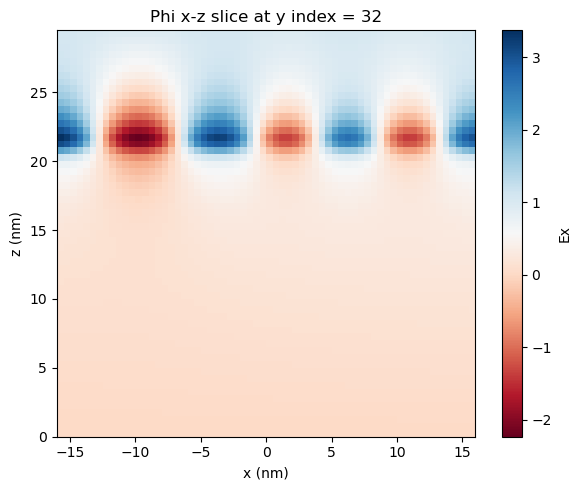

yt : [INFO     ] 2026-06-29 21:51:31,946 Parameters: current_time              = 5.767200000001402e-09


yt : [INFO     ] 2026-06-29 21:51:31,946 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:31,947 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:31,947 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


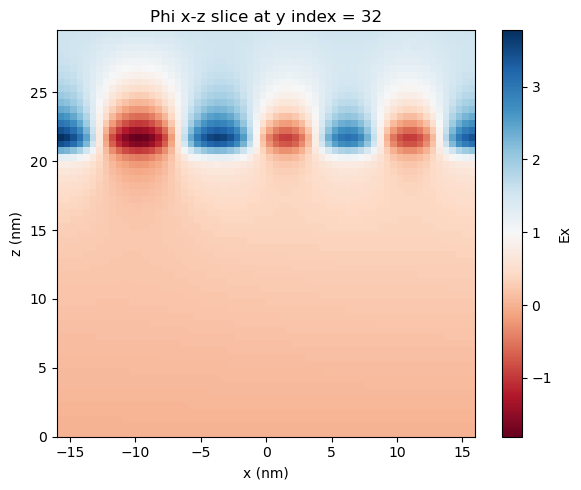

yt : [INFO     ] 2026-06-29 21:51:32,037 Parameters: current_time              = 5.943400000001456e-09


yt : [INFO     ] 2026-06-29 21:51:32,037 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:32,037 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:32,038 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


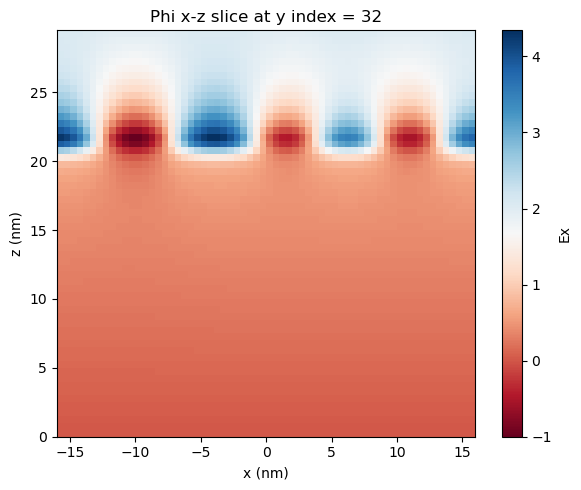

yt : [INFO     ] 2026-06-29 21:51:32,129 Parameters: current_time              = 6.234600000001545e-09


yt : [INFO     ] 2026-06-29 21:51:32,129 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:32,129 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:32,130 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


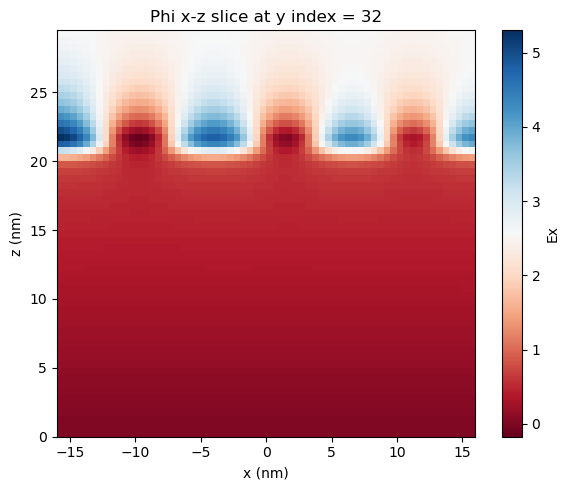

yt : [INFO     ] 2026-06-29 21:51:32,222 Parameters: current_time              = 6.500400000001627e-09


yt : [INFO     ] 2026-06-29 21:51:32,222 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:32,223 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:32,223 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


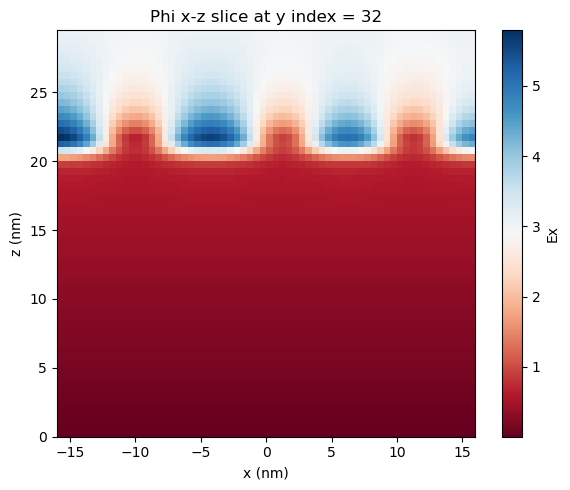

yt : [INFO     ] 2026-06-29 21:51:32,315 Parameters: current_time              = 7.706400000000938e-09


yt : [INFO     ] 2026-06-29 21:51:32,315 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:32,316 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:32,316 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


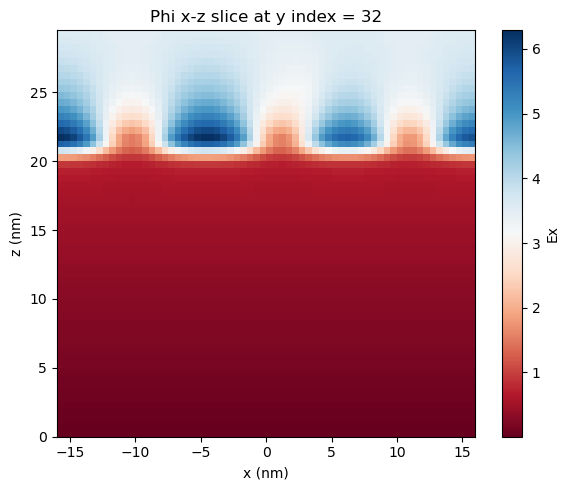

yt : [INFO     ] 2026-06-29 21:51:32,408 Parameters: current_time              = 8.302999999998653e-09


yt : [INFO     ] 2026-06-29 21:51:32,409 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:32,409 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:32,409 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


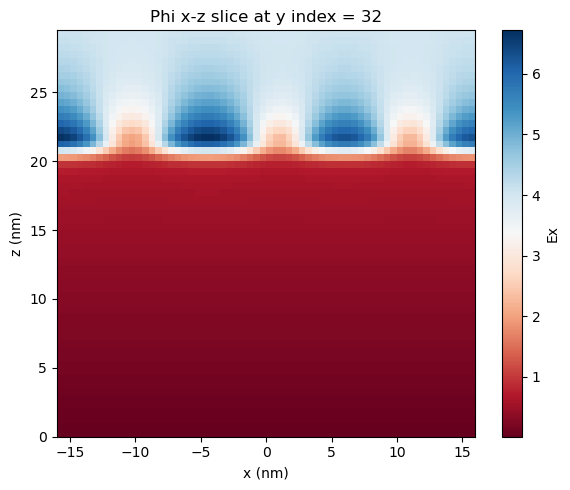

yt : [INFO     ] 2026-06-29 21:51:32,631 Parameters: current_time              = 9.612999999993637e-09


yt : [INFO     ] 2026-06-29 21:51:32,632 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:32,632 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:32,632 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


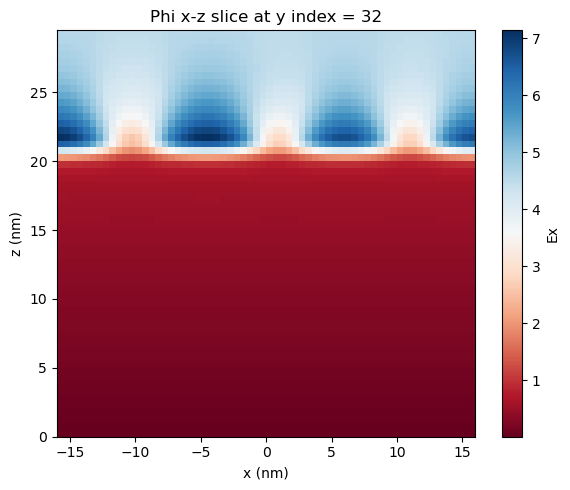

yt : [INFO     ] 2026-06-29 21:51:32,725 Parameters: current_time              = 1.0184599999991448e-08


yt : [INFO     ] 2026-06-29 21:51:32,725 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:32,725 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:32,725 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


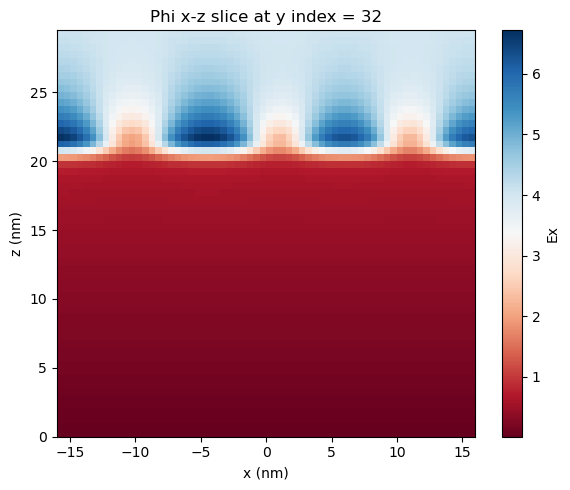

yt : [INFO     ] 2026-06-29 21:51:32,817 Parameters: current_time              = 1.0313999999990953e-08


yt : [INFO     ] 2026-06-29 21:51:32,818 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:32,818 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:32,818 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


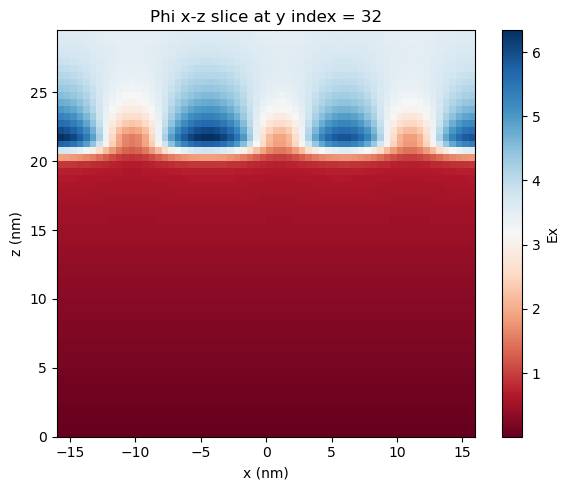

yt : [INFO     ] 2026-06-29 21:51:32,910 Parameters: current_time              = 1.0380799999990697e-08


yt : [INFO     ] 2026-06-29 21:51:32,910 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:32,911 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:32,911 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


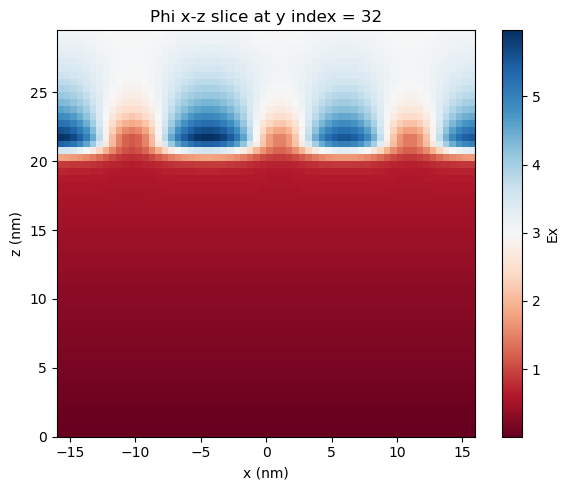

yt : [INFO     ] 2026-06-29 21:51:33,001 Parameters: current_time              = 1.0435999999990486e-08


yt : [INFO     ] 2026-06-29 21:51:33,001 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:33,001 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:33,002 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


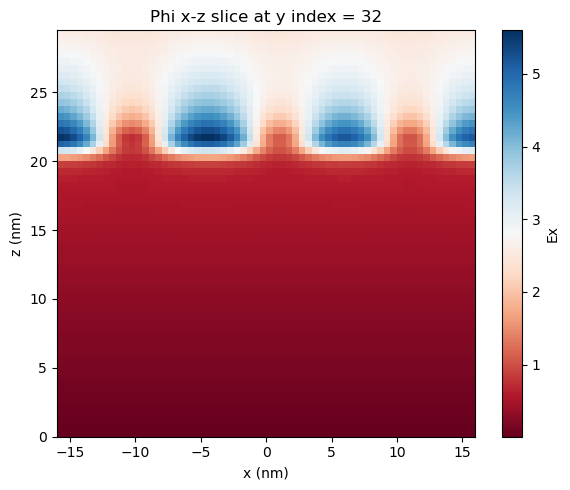

yt : [INFO     ] 2026-06-29 21:51:33,092 Parameters: current_time              = 1.065939999998963e-08


yt : [INFO     ] 2026-06-29 21:51:33,093 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:33,093 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:33,093 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


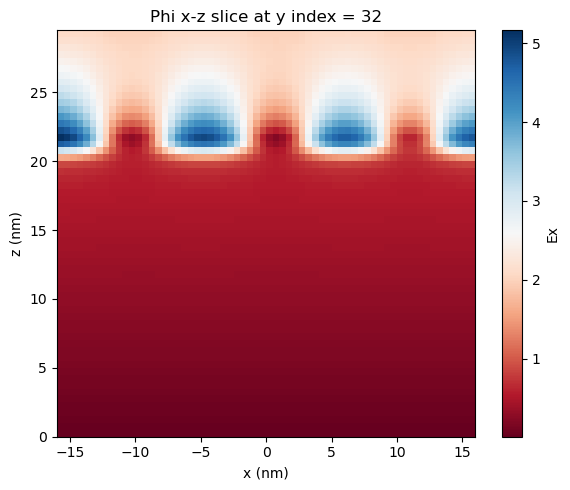

yt : [INFO     ] 2026-06-29 21:51:33,184 Parameters: current_time              = 1.0726799999989372e-08


yt : [INFO     ] 2026-06-29 21:51:33,184 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:33,185 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:33,185 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


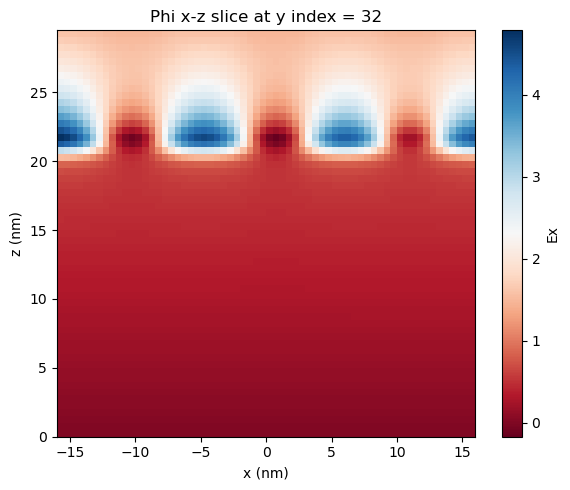

yt : [INFO     ] 2026-06-29 21:51:33,274 Parameters: current_time              = 1.0995399999988344e-08


yt : [INFO     ] 2026-06-29 21:51:33,274 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:33,275 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:33,275 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


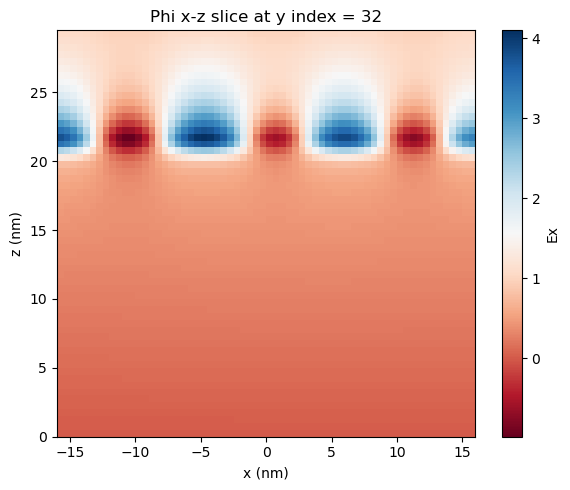

yt : [INFO     ] 2026-06-29 21:51:33,365 Parameters: current_time              = 1.1126199999987843e-08


yt : [INFO     ] 2026-06-29 21:51:33,366 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:33,366 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:33,366 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


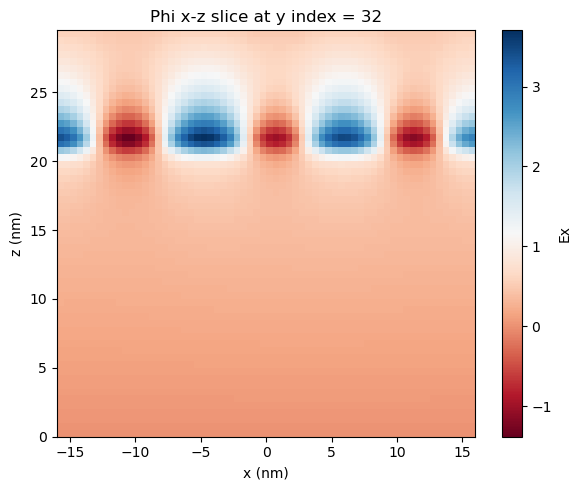

yt : [INFO     ] 2026-06-29 21:51:33,457 Parameters: current_time              = 1.1238799999987412e-08


yt : [INFO     ] 2026-06-29 21:51:33,457 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:33,457 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:33,457 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


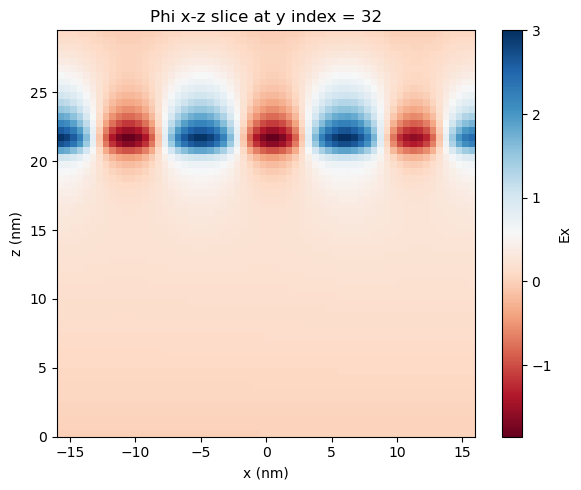

yt : [INFO     ] 2026-06-29 21:51:33,548 Parameters: current_time              = 1.1348399999986992e-08


yt : [INFO     ] 2026-06-29 21:51:33,549 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:33,549 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:33,549 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


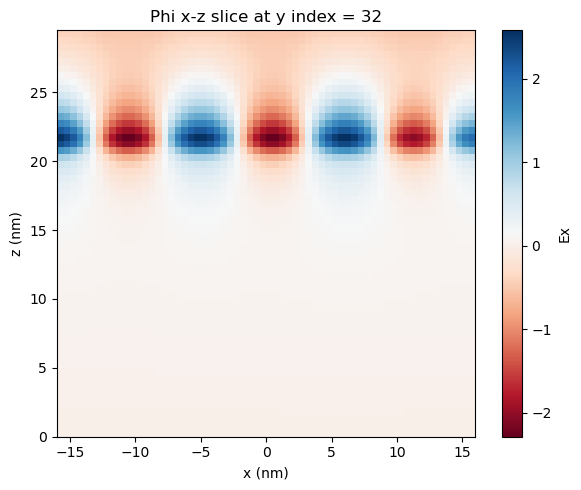

yt : [INFO     ] 2026-06-29 21:51:33,640 Parameters: current_time              = 1.1528799999986301e-08


yt : [INFO     ] 2026-06-29 21:51:33,640 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:33,640 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:33,640 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


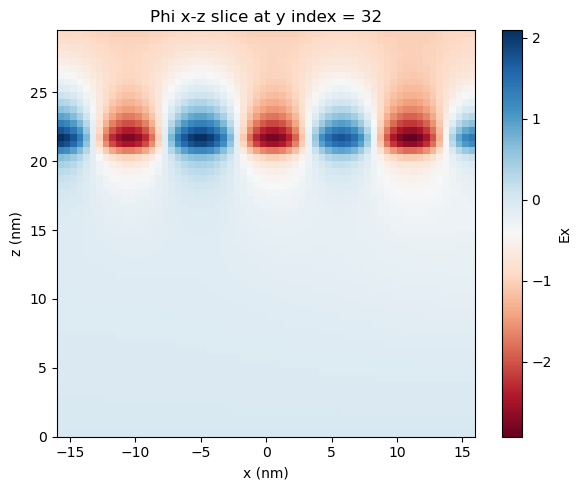

yt : [INFO     ] 2026-06-29 21:51:33,860 Parameters: current_time              = 1.1666799999985773e-08


yt : [INFO     ] 2026-06-29 21:51:33,860 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:33,860 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:33,860 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


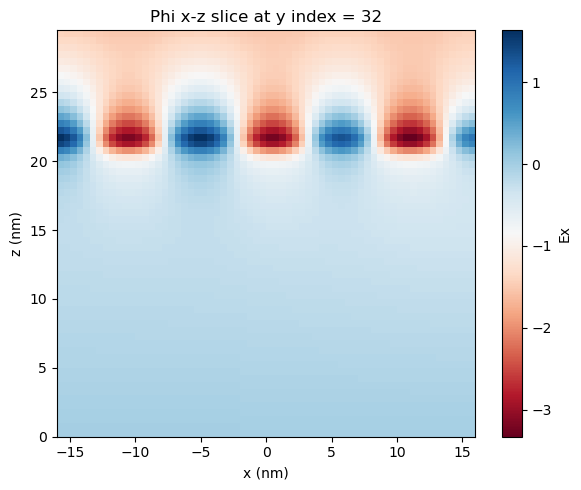

yt : [INFO     ] 2026-06-29 21:51:33,951 Parameters: current_time              = 1.181119999998522e-08


yt : [INFO     ] 2026-06-29 21:51:33,951 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:33,951 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:33,952 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


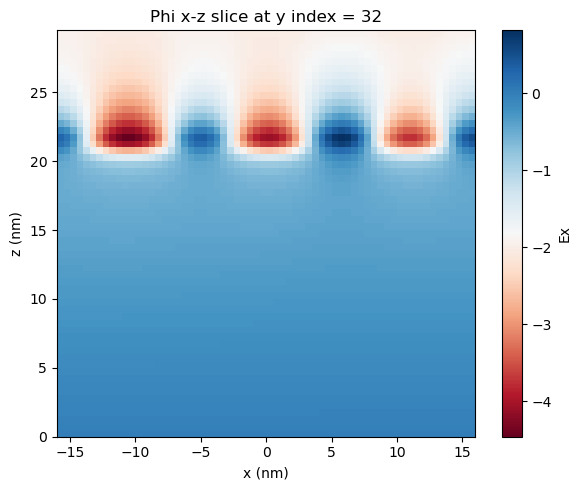

yt : [INFO     ] 2026-06-29 21:51:34,041 Parameters: current_time              = 1.1993399999984522e-08


yt : [INFO     ] 2026-06-29 21:51:34,042 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:34,042 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:34,042 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


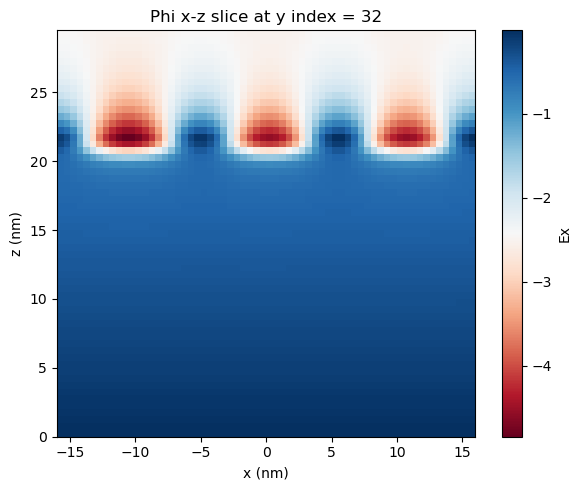

yt : [INFO     ] 2026-06-29 21:51:34,134 Parameters: current_time              = 1.2894199999981073e-08


yt : [INFO     ] 2026-06-29 21:51:34,134 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:34,134 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:34,134 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


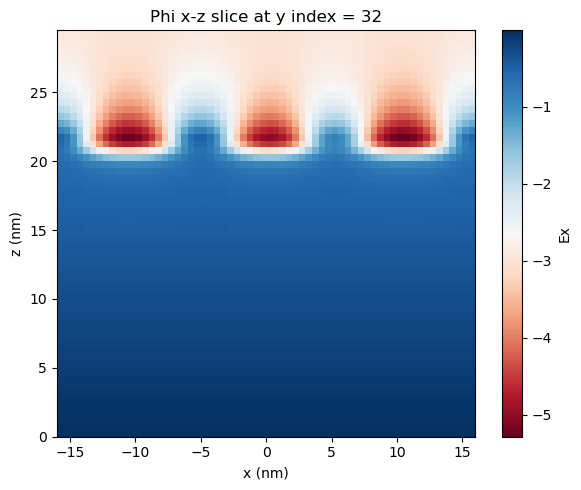

yt : [INFO     ] 2026-06-29 21:51:34,226 Parameters: current_time              = 1.3230199999979786e-08


yt : [INFO     ] 2026-06-29 21:51:34,227 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:34,227 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:34,227 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


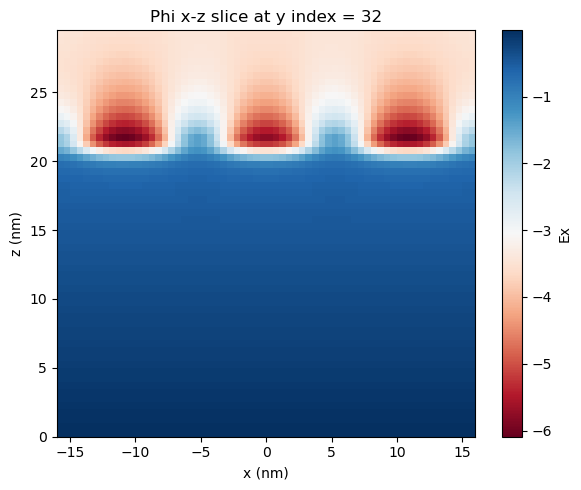

yt : [INFO     ] 2026-06-29 21:51:34,319 Parameters: current_time              = 1.4100399999976454e-08


yt : [INFO     ] 2026-06-29 21:51:34,320 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:34,320 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:34,320 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


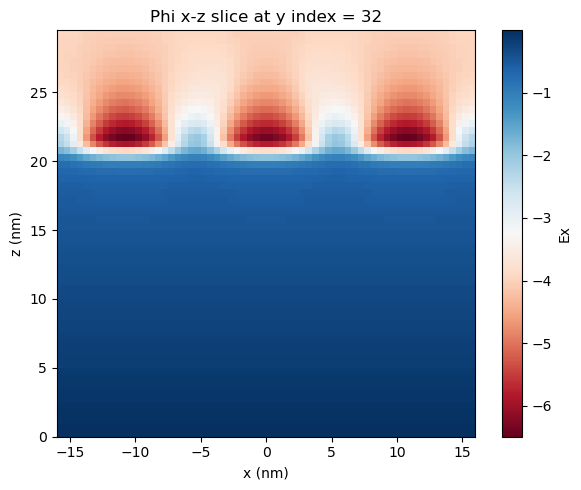

yt : [INFO     ] 2026-06-29 21:51:34,413 Parameters: current_time              = 1.4577799999974626e-08


yt : [INFO     ] 2026-06-29 21:51:34,413 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:34,413 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:34,413 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


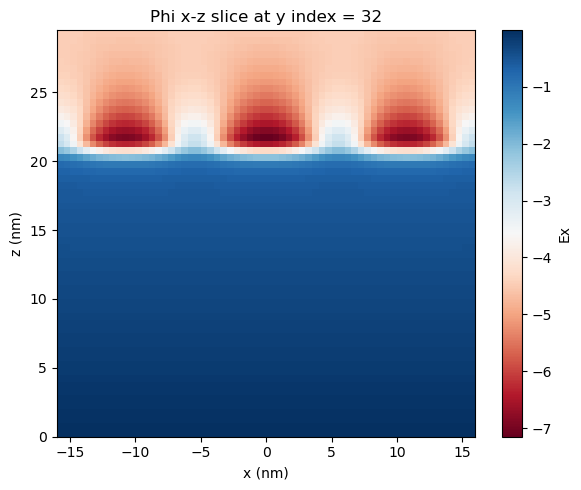

In [13]:
import yt
import numpy as np
import matplotlib.pyplot as plt
for i in range(len(plot_names)):
    plotfile = PLOT_DIR/plot_names[i] 
    field = ("boxlib", "Phi")

    ds = yt.load(plotfile)

    #g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
    Phi_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid

    print("Phi_array shape =", Phi_array.shape)

    Nx, Ny, Nz = Phi_array.shape #用index存資料

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dims = np.array([Nx, Ny, Nz])

    dx = (hi - lo) / dims

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    y0 = Ny // 2
    slice2d = Phi_array[:, y0, :]

    plt.figure(figsize=(6, 5))
    im = plt.pcolormesh(
        x_nm,
        z_nm,
        slice2d.T,
        shading="auto",
        cmap="RdBu"
    )

    plt.colorbar(im, label="Ex")
    plt.xlabel("x (nm)")
    plt.ylabel("z (nm)")
    plt.title(f"Phi x-z slice at y index = {y0}")
    plt.tight_layout()
    plt.show()

yt : [INFO     ] 2026-06-29 21:51:34,510 Parameters: current_time              = 1.8340000000000275e-10


yt : [INFO     ] 2026-06-29 21:51:34,511 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:34,511 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:34,511 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


E_array shape = (64, 64, 59)


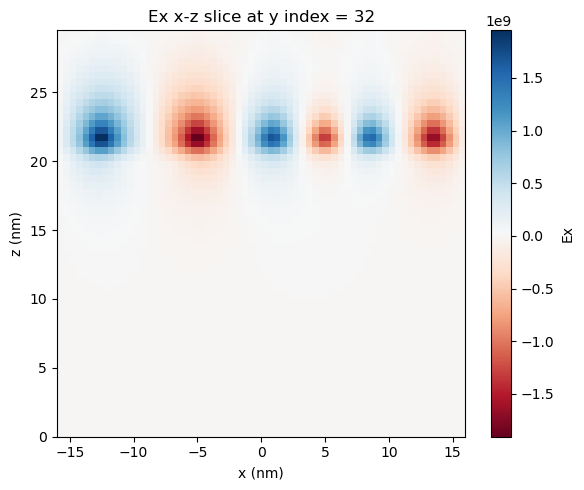

In [14]:
import yt
import numpy as np
import matplotlib.pyplot as plt

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_plt")  # 改成你 plotfile 所在的資料夾
plotfile = PLOT_DIR/plot_names[2] 
field = ("boxlib", "Ex")

ds = yt.load(plotfile)

#g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
E_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Ex 資料，會自動合併多個 grid

print("E_array shape =", E_array.shape)

Nx, Ny, Nz = E_array.shape #用index存資料

lo = ds.domain_left_edge.to_value()
hi = ds.domain_right_edge.to_value()
dims = np.array([Nx, Ny, Nz])

dx = (hi - lo) / dims

x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

y0 = Ny // 2
slice2d = E_array[:, y0, :]

plt.figure(figsize=(6, 5))
im = plt.pcolormesh(
    x_nm,
    z_nm,
    slice2d.T,
    shading="auto",
    cmap="RdBu"
)

plt.colorbar(im, label="Ex")
plt.xlabel("x (nm)")
plt.ylabel("z (nm)")
plt.title(f"Ex x-z slice at y index = {y0}")
plt.tight_layout()
plt.show()

## 2D Pz slice plot(all voltage in same graph)

yt : [INFO     ] 2026-06-29 21:51:34,616 Parameters: current_time              = 3.528200000000715e-09


yt : [INFO     ] 2026-06-29 21:51:34,616 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:34,616 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:34,616 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Plotfiles to draw:
  plt00017641
  plt00019509
  plt00020163
  plt00021023
  plt00021296
  plt00023826
  plt00024471
  plt00024985
  plt00025571
  plt00026429
  plt00027355
  plt00028381
  plt00028836
  plt00029717
  plt00031173
  plt00032502
  plt00038532
  plt00041515
  plt00048065
  plt00050923
  plt00051570
  plt00051904
  plt00052180
  plt00053297
  plt00053634
  plt00054977
  plt00055631
  plt00056194
  plt00056742
  plt00057644
  plt00058334
  plt00059056
  plt00059967
  plt00064471
  plt00066151
  plt00070502
  plt00072889
37 number of plotfiles will be drawn after filtering.


...

yt : [INFO     ] 2026-06-29 21:51:36,379 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:36,379 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:36,380 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Drawing 37 plots after filtering.


Saved figure: ./figs/Pz_FE_layer_stack.png


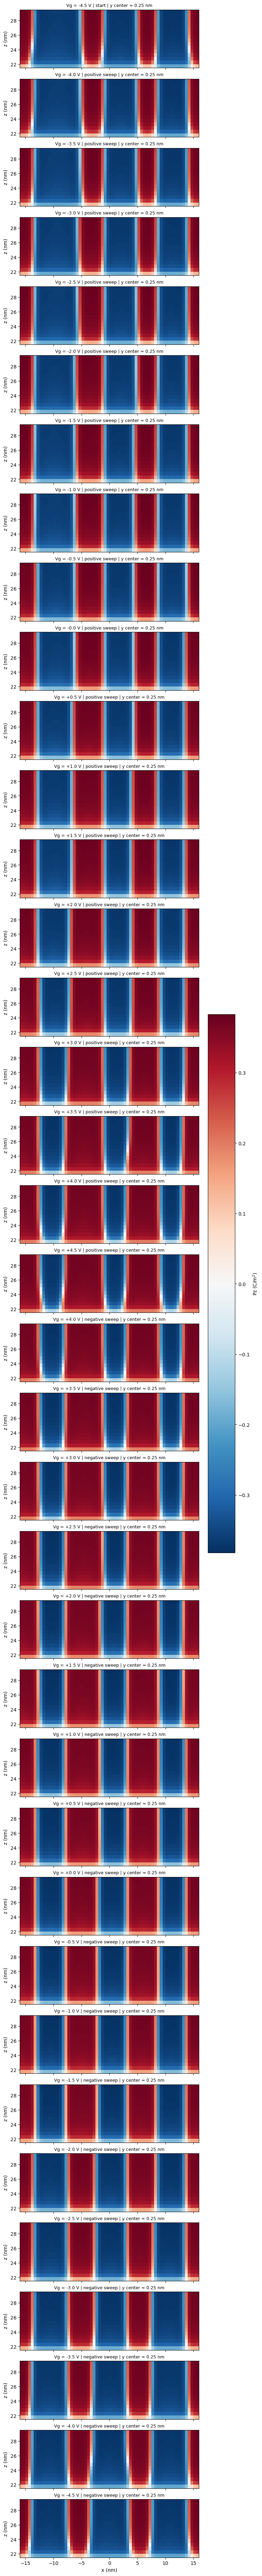

In [15]:
from pathlib import Path
import re

import yt
import numpy as np
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec")          # plotfile 所在資料夾
P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")

# ==========================
# Selection list (NEW)
# ==========================
# format: (voltage, direction)
# voltage 用 None 表示 wildcard
# direction 用 None 表示 wildcard
'''
SELECT_LIST = [
    
    (-0.5, "positive sweep"), 
    (-0.5, "negative sweep"),
   
]
'''
SELECT_LIST = None  # 不過濾，全部畫出來
USE_FE_X_RANGE = False

# y slice: None 表示取 y 方向正中間
Y_INDEX = None

# 若 plot_names 已經是你前面整理好的 steady-state plot list，就直接用
# plot_names = [...]
# 若沒有，就自動抓目前資料夾內所有 plt########
AUTO_FIND_PLOTS = False

# 跳過 initial plt00000000
SKIP_INITIAL = True

# 色階是否對稱於 0，畫 Pz 通常建議 True
SYMMETRIC_COLOR_SCALE = False

# 輸出圖片名稱
SAVE_FIG = True
OUT_FIG = "./figs/Pz_FE_layer_stack.png"


# ==========================
# Helper functions
# ==========================


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v


def read_one_plot(plotfile, y_index=None):
    ds = yt.load(str(plotfile))
    #g = ds.index.grids[0]

    P = read_full_field_from_grids(ds, P_FIELD) # 讀取整個 domain 的 Pz 資料，會自動合併多個 grid
    P*=-1
    if PHI_FIELD in ds.field_list:
        Phi = read_full_field_from_grids(ds, PHI_FIELD) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid
    else:
        Phi = None

    Nx, Ny, Nz = P.shape

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    if y_index is None:
        y_index = Ny // 2

    # FE z range mask
    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    # P slice: shape after selection = (Nx_sel, Nz_sel)
    P_slice = P[np.ix_(x_sel, [y_index], z_sel)][:, 0, :]

    x_plot = x_nm[x_sel]
    z_plot = z_nm[z_sel]

    # 用最上層 cell 的 Phi 平均值當 top potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    if Phi is not None:
        top_phi = Phi[:, :, -1]
        Vtop_mean = float(np.mean(top_phi))
        Vtop_min = float(np.min(top_phi))
        Vtop_max = float(np.max(top_phi))
    else:
        Vtop_mean = np.nan
        Vtop_min = np.nan
        Vtop_max = np.nan

    info = {
        "ds": ds,
        "P_slice": P_slice,
        "x_nm": x_plot,
        "z_nm": z_plot,
        "y_index": y_index,
        "y_nm": float(y_nm[y_index]),
        "Vtop_mean": Vtop_mean,
        "Vtop_min": Vtop_min,
        "Vtop_max": Vtop_max,
        "shape": P.shape,
    }

    return info



def match(rec, direction):# FILTER BY SELECT_LIST
    if not SELECT_LIST:
        return True
    V = rec["Vtop_mean"]

    for v_target, d_target in SELECT_LIST:

        ok_v = (v_target is None) or (
            np.isfinite(V) and np.isclose(V, v_target, atol=1e-1)
        )

        ok_d = (d_target is None) or (direction == d_target)

        if ok_v and ok_d:
            return True

    return False

# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

# sort by step if names are plt########
plot_names_use = sorted(plot_names_use, key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]

#忽略第一段
plot_names_use = plot_names_use[9:]
    
print("Plotfiles to draw:")
for n in plot_names_use:
    print(" ", n)
print(len(plot_names_use), "number of plotfiles will be drawn after filtering.")

records = []
all_values = []

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    info = read_one_plot(plotfile, y_index=Y_INDEX)

    step = get_step_from_name(name)

    records.append({
        "name": name,
        "step": step,
        **info,
    })

    all_values.append(info["P_slice"])

# shared color scale
all_concat = np.concatenate([v.ravel() for v in all_values])
if SYMMETRIC_COLOR_SCALE:
    vmax = np.nanmax(np.abs(all_concat))
    vmin = -vmax
else:
    vmin = np.nanmin(all_concat)
    vmax = np.nanmax(all_concat)

# determine sweep direction from Vtop sequence
Vseq = np.array([r["Vtop_mean"] for r in records], dtype=float)

directions = []
for idx, V in enumerate(Vseq):
    if idx == 0 or not np.isfinite(Vseq[idx-1]) or not np.isfinite(V):
        directions.append("start")
    else:
        dV = V - Vseq[idx-1]
        if dV > 1e-8:
            directions.append("positive sweep")
        elif dV < -1e-8:
            directions.append("negative sweep")
        else:
            directions.append("same V")

filtered_records = []
filtered_directions = []

for rec, d in zip(records, directions):
    if match(rec, d):
        filtered_records.append(rec)
        filtered_directions.append(d)

records = filtered_records
directions = filtered_directions

# figure size
n = len(records)
print(f"Drawing {n} plots after filtering.")
fig_height = max(2.0 * n, 4.0)
fig, axes = plt.subplots(
    nrows=n,
    ncols=1,
    figsize=(7.5, fig_height),
    sharex=True,
    constrained_layout=True
)


if n == 1:
    axes = [axes]

last_im = None

for ax, rec, sweep_dir in zip(axes, records, directions):
    P_slice = rec["P_slice"]
    x_nm = rec["x_nm"]
    z_nm = rec["z_nm"]

    last_im = ax.pcolormesh(
        x_nm,
        z_nm,
        P_slice.T,
        shading="auto",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax
    )

    Vmean = rec["Vtop_mean"]
    Vmin = rec["Vtop_min"]
    Vmax = rec["Vtop_max"]

    if np.isfinite(Vmean):
        v_label = f"Vg = {Vmean:+.1f} V"
        # 若你想檢查 top x/y variation，也可以顯示 min/max
        # v_label += f" [{Vmin:+.3f}, {Vmax:+.3f}]"
    else:
        v_label = "Vtop unavailable"

    step_label = f"step={rec['step']}" if rec["step"] is not None else rec["name"]

    ax.set_ylabel("z (nm)")

    ax.set_title(
        f"{v_label} | {sweep_dir} | "
        f"y center ≈ {rec['y_nm']:.2f} nm",
        fontsize=9
    )

axes[-1].set_xlabel("x (nm)")
axes[-1].tick_params(axis='x', labelbottom=True)
'''
for ax in axes:
    ax.set_xlabel("x (nm)")
    ax.tick_params(axis='x', labelbottom=True)
'''
cbar = fig.colorbar(last_im, ax=axes, shrink=0.8)
cbar.set_label(r"Pz (C/m$^2$)")

if SAVE_FIG:
    fig.savefig(OUT_FIG, dpi=200)
    print(f"Saved figure: {OUT_FIG}")

plt.show()

## PV

### User Settings

In [16]:
from pathlib import Path
import re

import yt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_1_plt")

P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")


# 如果 FE 是全幅 MFIS，通常不用限制 x/y
USE_FE_X_RANGE = False


USE_FE_Y_RANGE = False
# 若你已經有 steady-state plot_names，就用 AUTO_FIND_PLOTS=False
# plot_names = [...]
AUTO_FIND_PLOTS = True

# 如果沒有 plot_names，可以自動找所有 plt########
# 但建議最好只用 steady-state plotfiles
SKIP_INITIAL = True

OUT_CSV = "./figs/MFIS_PV_curve.csv"
OUT_FIG = "./figs/MFIS_PV_curve.png"


### Utils

In [17]:
# ==========================
# Helper functions
# ==========================

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

def read_pv_from_plot(plotfile):
    ds = yt.load(str(plotfile))
    Pz = read_full_field_from_grids(ds, P_FIELD)
    Phi = read_full_field_from_grids(ds, PHI_FIELD)

    Nx, Ny, Nz = Pz.shape
    print(f"Read Pz with shape {Pz.shape} from {plotfile}")

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    print(f"Domain: x [{lo[0]:.3e}, {hi[0]:.3e}] m, "
          f"y [{lo[1]:.3e}, {hi[1]:.3e}] m, "
          f"z [{lo[2]:.3e}, {hi[2]:.3e}] m")
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    if USE_FE_Y_RANGE:
        y_sel = (y_nm >= FE_Y_LO_NM) & (y_nm <= FE_Y_HI_NM)
    else:
        y_sel = np.ones_like(y_nm, dtype=bool)

    Pz_FE = Pz[np.ix_(x_sel, y_sel, z_sel)]

    P_mean = float(np.mean(Pz_FE))
    P_min = float(np.min(Pz_FE))
    P_max = float(np.max(Pz_FE))
    P_std = float(np.std(Pz_FE))

    # 用最上層 cell 的 Phi 平均值估 top electrode potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    top_phi = Phi[:, :, -1]
    Vg_mean = float(np.mean(top_phi))
    Vg_min = float(np.min(top_phi))
    Vg_max = float(np.max(top_phi))
    Vg_std = float(np.std(top_phi))

    return {
        "P_mean": P_mean,
        "P_min": P_min,
        "P_max": P_max,
        "P_std": P_std,
        "Vg_mean": Vg_mean,
        "Vg_min": Vg_min,
        "Vg_max": Vg_max,
        "Vg_std": Vg_std,
        "Nx": Nx,
        "Ny": Ny,
        "Nz": Nz,
        "num_FE_cells": int(Pz_FE.size),
    }



### Data Preparation

In [18]:



# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    print(f"Finding plotfiles in {PLOT_DIR}...")
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

plot_names_use = sorted(
    plot_names_use,
    key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99
)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]
plot_names_use = plot_names_use[9:]  # skip first 9 plotfiles
rows = []

print(plot_names_use)

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    step = get_step_from_name(name)

    info = read_pv_from_plot(plotfile)

    rows.append({
        "plotfile": name,
        "step": step,
        **info,
    })

    print(
        f"{name} | step={step} | "
        f"Vg={info['Vg_mean']:+.4f} V | "
        f"<Pz>_FE={info['P_mean']:+.6e}"
    )

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)
print(f"Saved CSV: {OUT_CSV}")


# ==========================
# Determine sweep direction
# ==========================

V = df["Vg_mean"].to_numpy()
P = df["P_mean"].to_numpy()


direction = np.zeros_like(V)

for i in range(1, len(V)):
    dV = V[i] - V[i - 1]
    if dV > 1e-8:
        direction[i] = 1   # positive sweep
    elif dV < -1e-8:
        direction[i] = -1  # negative sweep
    else:
        direction[i] = direction[i - 1]

#np.append(direction, direction[-1])  # 複製第一筆到最後

df["sweep_direction"] = direction
df.to_csv(OUT_CSV, index=False)




yt : [INFO     ] 2026-06-29 21:51:39,311 Parameters: current_time              = 3.528200000000715e-09


yt : [INFO     ] 2026-06-29 21:51:39,311 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:39,311 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:39,311 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


yt : [INFO     ] 2026-06-29 21:51:39,356 Parameters: current_time              = 3.9018000000008296e-09


...

yt : [INFO     ] 2026-06-29 21:51:41,030 Parameters: current_time              = 1.4577799999974626e-08


yt : [INFO     ] 2026-06-29 21:51:41,030 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 21:51:41,030 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 21:51:41,030 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Read Pz with shape (64, 64, 59) from plts/plt00070502
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00070502 | step=70502 | Vg=-3.9966 V | <Pz>_FE=+8.329653e-02
Read Pz with shape (64, 64, 59) from plts/plt00072889
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00072889 | step=72889 | Vg=-4.5061 V | <Pz>_FE=+9.950501e-02
Saved CSV: ./figs/MFIS_PV_curve.csv


### plot pv

In [19]:
print(len(P))

37


Saved figure: ./figs/MFIS_PV_curve.png


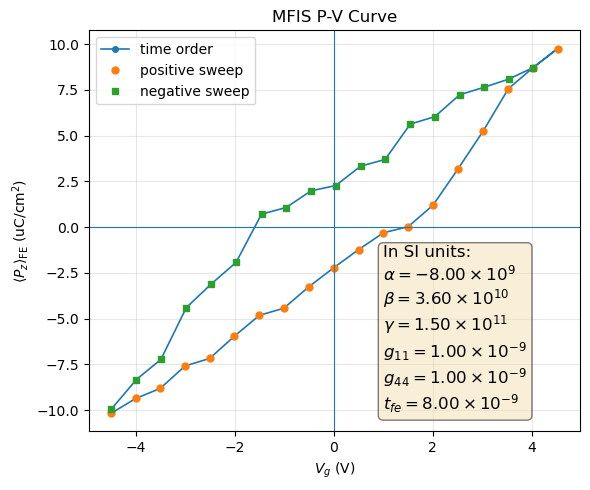

In [20]:
def sci_tex(x, sig=2):
    """Return LaTeX like 1.23\\times10^{-4} (no 'e')."""
    if x == 0:
        return r"0"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / (10 ** exp)
    return rf"{mant:.{sig}f}\times 10^{{{exp}}}"

# ==========================
# Plot PV curve
# ==========================

plt.figure(figsize=(6, 5))

textstr = '\n'.join((
    r'In SI units:',
    rf'$\alpha={sci_tex(ALPHA, sig=2)}$',
    rf'$\beta={sci_tex(BETA, sig=2)}$',
    rf'$\gamma={sci_tex(SMALL_GAMMA, sig=2)}$',
    rf'$g_{{11}}={sci_tex(G11, sig=2)}$',
    rf'$g_{{44}}={sci_tex(G44, sig=2)}$',
    rf'$t_{{fe}}={sci_tex((FE_Z_HI_NM-FE_Z_LO_NM)*1e-9, sig=2)}$',
))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(1, -1, textstr, fontsize=12,
        verticalalignment='top', bbox=props)

# time-order full loop
plt.plot(V, -P*100, "-o", markersize=4, linewidth=1.2, label="time order")
# paper data
#plt.plot(Vp, Pp, "-o", markersize=4, linewidth=1.2, label="paper")
# no f data
#plt.plot(Vnf, -Pnf*100, "-o", markersize=4, linewidth=1.2, label="before")
# optional: highlight positive / negative sweep
pos = df["sweep_direction"].to_numpy() >= 0
neg = df["sweep_direction"].to_numpy() < 0

if np.any(pos):
    plt.plot(V[pos], -P[pos]*100, "o", markersize=5, label="positive sweep")

if np.any(neg):
    plt.plot(V[neg], -P[neg]*100, "s", markersize=5, label="negative sweep")


plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel(r"$V_g$ (V)")
plt.ylabel(r"$\langle P_z \rangle_\mathrm{FE}$ (uC/cm$^2$)")
plt.title("MFIS P-V Curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(OUT_FIG, dpi=200)
print(f"Saved figure: {OUT_FIG}")

plt.show()

# update html

## utils

In [21]:
from pathlib import Path
from datetime import datetime
import re


def make_image_cell(img_path):
    if img_path is None or img_path == "":
        return "<td>No Image</td>"

    return f"""
<td>
<a href="{img_path}" target="_blank">
<img src="{img_path}">
</a>
</td>
"""


def update_dashboard(
    folder,
    params,
    tfe,
    start_time=None,
    end_time=None,
    elapsed_time=None,
    pv=None,
    pz=None,
    html_file="index.html",
):
    """
    folder : 資料夾名稱 (例如 MFIS001)

    params : dict
        {
            "alpha":...,
            "beta":...,
            ...
        }

    tfe : float

    pv,pz : 相對於 index.html 的圖片路徑
    """

    html_file = Path(html_file)

    with open(html_file, encoding="utf8") as f:
        html = f.read()

    # ---------- 防止重複 ----------
    
    folders = set(
        re.findall(
            r'<tr>\s*<td[^>]*>(.*?)</td>',
            html,
            re.DOTALL
        )
    )

    if folder in folders:
        print(f"{folder} already exists. Skip.")
        return

    # ---------- 更新時間 ----------
    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    html = re.sub(
        r'(<span id="last_update">).*?(</span>)',
        rf"\g<1>{now}\g<2>",
        html,
        flags=re.S,
    )

    # ---------- 更新總數 ----------
    # 網頁java自動更新總數，這裡不需要

    
    # ---------- 新增一列 ----------
    row = f'<tr>\n<td>{folder}</td>'

    wanted = [
        "alpha",
        "beta",
        "gamma",
        "BigGamma",
        "g11",
        "g44",
        "FE_lo",
        "FE_hi",
    ]

    for p in wanted:
        if p == "FE_lo" or p == "FE_hi":
            continue
            
        value = params.get(p)

        if value is None:
            txt = ""

        elif isinstance(value, list):
            txt = " ".join(f"{v:.3e}" for v in value)

        else:
            txt = f"{value:.3e}"

        row += f'<td>{txt}</td>'

    row += f'<td>{tfe:.3e}</td>'
    row += f'<td>{start_time}</td>'
    row += f'<td>{end_time}</td>'
    row += f'<td>{elapsed_time}</td>'
    
    

    row += make_image_cell(pv)

    row += make_image_cell(pz)

    row += "\n</tr>\n"
    
    html = html.replace(
        "</tbody>",
        row + "</tbody>",
    )

    with open(html_file, "w", encoding="utf8") as f:
        f.write(html)

    print(f"{folder} added.")

## main

In [22]:
from pathlib import Path

folder = Path.cwd().name
cwd = Path.cwd()

root = cwd.parent

pv = (cwd / "figs" / "MFIS_PV_curve.png").relative_to(root).as_posix()

pz = (cwd / "figs" / "Pz_FE_layer_stack.png").relative_to(root).as_posix()

update_dashboard(
    folder=folder,
    params=params,
    tfe=T_FE,
    start_time=start_time,
    end_time=end_time,
    elapsed_time=elapsed_hms,
    pv=pv,
    pz=pz,
    html_file=root / "index.html",
)




MFIS_t_8_nomi_22 added.
